# Spam dataset with ensemble methods

### Importing packages

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

np.random.seed(0)

### Plotting functions

In [7]:
# Some functions to plot our points and draw the lines
def plot_points(features, labels, fix_margins=True):
    X = np.array(features)
    y = np.array(labels)
    spam = X[np.argwhere(y==1)]
    ham = X[np.argwhere(y==0)]
    if fix_margins:
        plt.xlim(0, 11)
        plt.ylim(0, 11)
    plt.scatter([s[0][0] for s in spam],
                [s[0][1] for s in spam],
                s = 100,
                color = 'cyan',
                edgecolor = 'k',
                marker = '^')
    plt.scatter([s[0][0] for s in ham],
                [s[0][1] for s in ham],
                s = 100,
                color = 'red',
                edgecolor = 'k',
                marker = 's')
    plt.xlabel('Lottery')
    plt.ylabel('Sale')
    plt.legend(['Spam','Ham'])

def plot_model(X, y, model, fix_margins=True):
    X = np.array(X)
    y = np.array(y)
    plot_points(X, y)
    plot_step = 0.01
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    if fix_margins:
        x_min=0
        y_min=0
        x_max=12
        y_max=12
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, colors=['red', 'blue'], alpha=0.2, levels=range(-1,2))
    plt.contour(xx, yy, Z,colors = 'k',linewidths = 3)
    plt.show()

def display_tree(dt):
    import matplotlib.pyplot as plt
    from sklearn.tree import plot_tree

    plt.figure(figsize=(12, 8))
    plot_tree(
        dt,
        filled=True,
        rounded=True
    )
    plt.show()

# The spam email dataset

In [3]:
emails = np.array([
    [7,8,1],
    [3,2,0],
    [8,4,1],
    [2,6,0],
    [6,5,1],
    [9,6,1],
    [8,5,0],
    [7,1,0],
    [1,9,1],
    [4,7,0],
    [1,3,0],
    [3,10,1],
    [2,2,1],
    [9,3,0],
    [5,3,0],
    [10,1,0],
    [5,9,1],
    [10,8,1],
])
spam_dataset = pd.DataFrame(data=emails, columns=["Lottery", "Sale", "Spam"])
spam_dataset

,Lottery,Sale,Spam
0,7,8,1
1,3,2,0
2,8,4,1
3,2,6,0
4,6,5,1
5,9,6,1
6,8,5,0
7,7,1,0
8,1,9,1
9,4,7,0


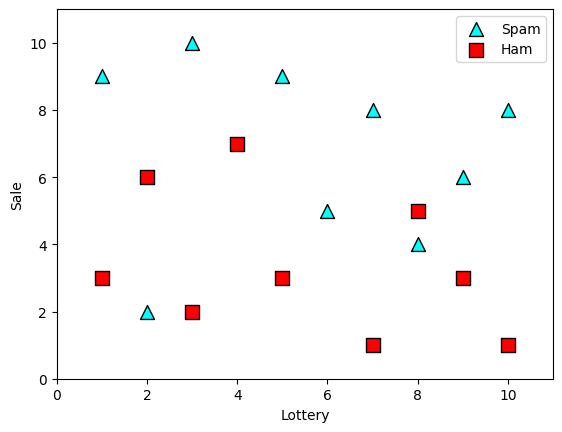

In [4]:
features = spam_dataset[['Lottery', 'Sale']]
labels = spam_dataset['Spam']
plot_points(features, labels)

In [5]:
decision_tree_classifier = DecisionTreeClassifier(random_state=0)
decision_tree_classifier.fit(features, labels)
decision_tree_classifier.score(features, labels)

1.0

# Training a decision tree

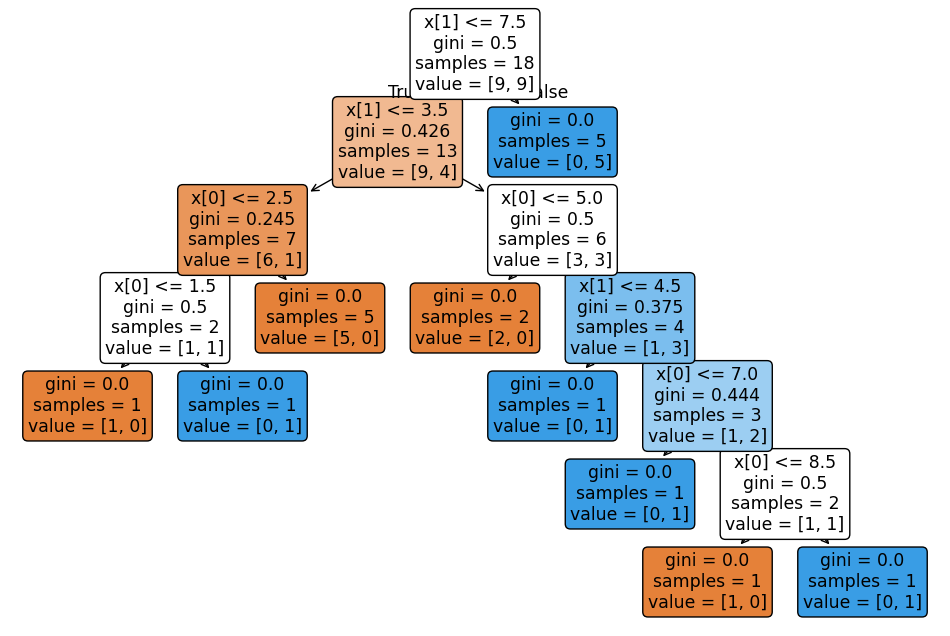

In [8]:
display_tree(decision_tree_classifier)

/Users/khanhlinhpham/Documents/manning/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


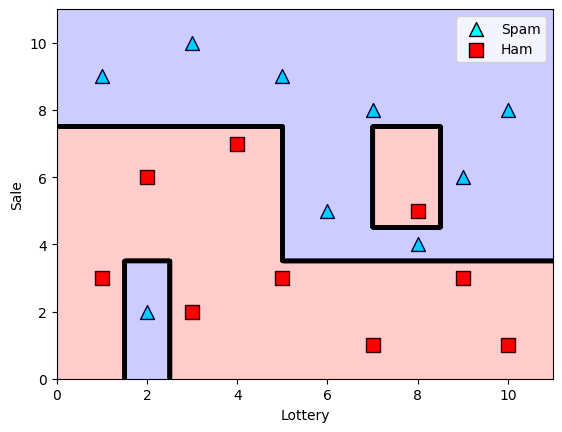

In [9]:
plot_model(features, labels, decision_tree_classifier)

# Training a random forest by hand

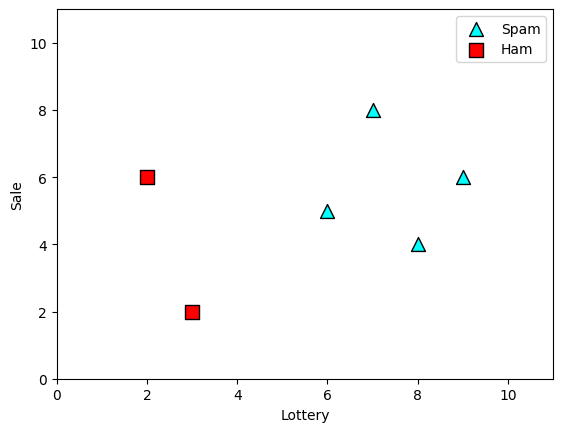

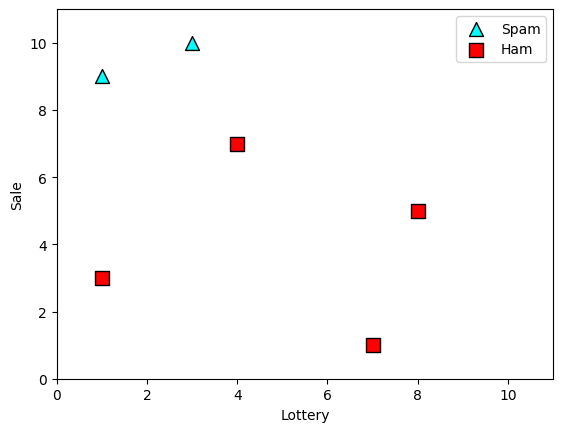

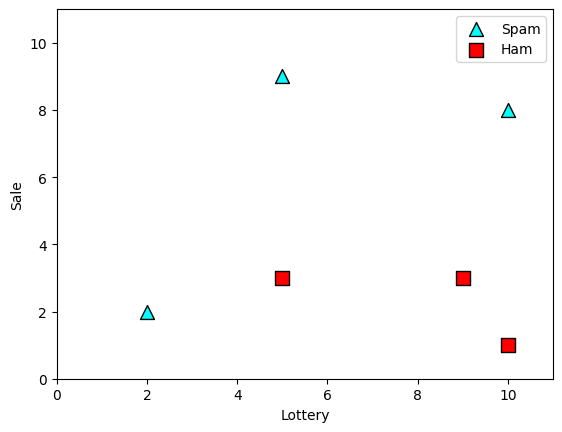

In [10]:
first_batch = spam_dataset.loc[[0,1,2,3,4,5]]
features1 = first_batch[['Lottery', 'Sale']]
labels1 = first_batch['Spam']
plot_points(features1, labels1)
plt.show()

second_batch = spam_dataset.loc[[6,7,8,9,10,11]]
features2 = second_batch[['Lottery', 'Sale']]
labels2 = second_batch['Spam']
plot_points(features2, labels2)
plt.show()

third_batch = spam_dataset.loc[[12,13,14,15,16,17]]
features3 = third_batch[['Lottery', 'Sale']]
labels3 = third_batch['Spam']
plot_points(features3, labels3)

Weak learner 1 training accuracy: 1.0


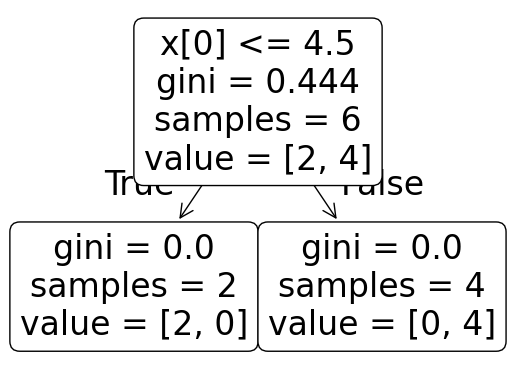

/Users/khanhlinhpham/Documents/manning/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


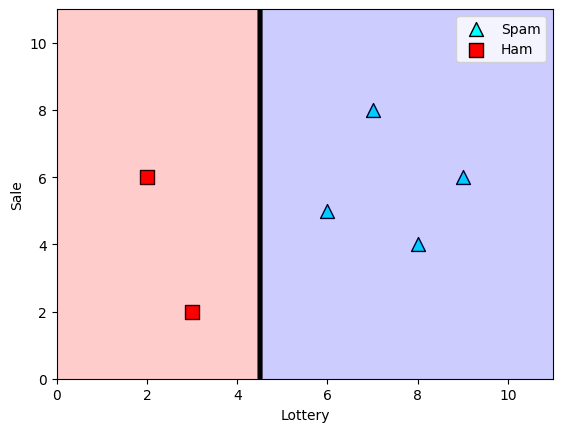

Weak learner 2 training accuracy: 1.0


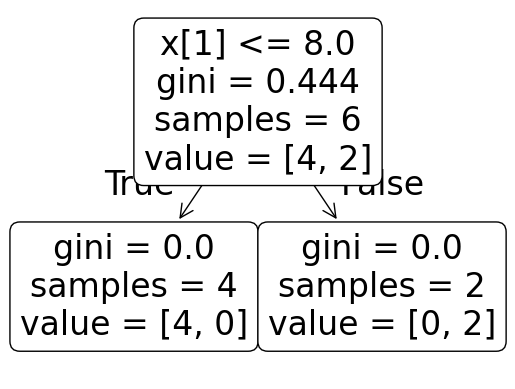

/Users/khanhlinhpham/Documents/manning/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


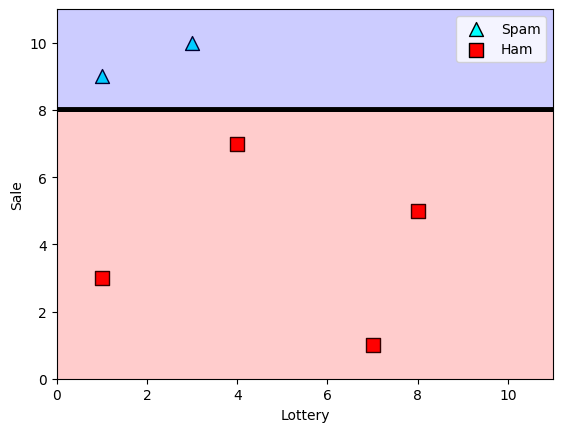

Weak learner 3 training accuracy: 0.8333333333333334


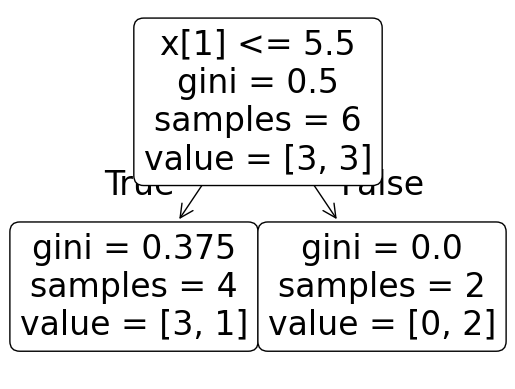

/Users/khanhlinhpham/Documents/manning/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


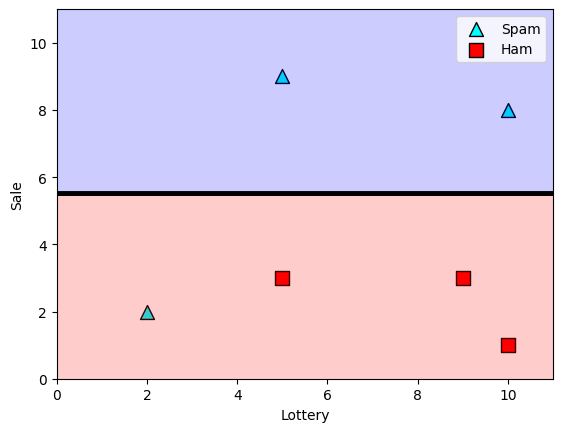

In [14]:
dt1 = DecisionTreeClassifier(random_state=0, max_depth=1)
dt1.fit(features1, labels1)
print("Weak learner 1 training accuracy:", dt1.score(features1, labels1))
tree.plot_tree(dt1, rounded=True)
plt.show()
plot_model(features1, labels1, dt1)

dt2 = DecisionTreeClassifier(random_state=0, max_depth=1)
dt2.fit(features2, labels2)
print("Weak learner 2 training accuracy:", dt2.score(features2, labels2))
tree.plot_tree(dt2, rounded=True)
plt.show()
plot_model(features2, labels2, dt2)

dt3 = DecisionTreeClassifier(random_state=0, max_depth=1)
dt3.fit(features3, labels3)
print("Weak learner 3 training accuracy:", dt3.score(features3, labels3))
tree.plot_tree(dt3, rounded=True)
plt.show()
plot_model(features3, labels3, dt3)

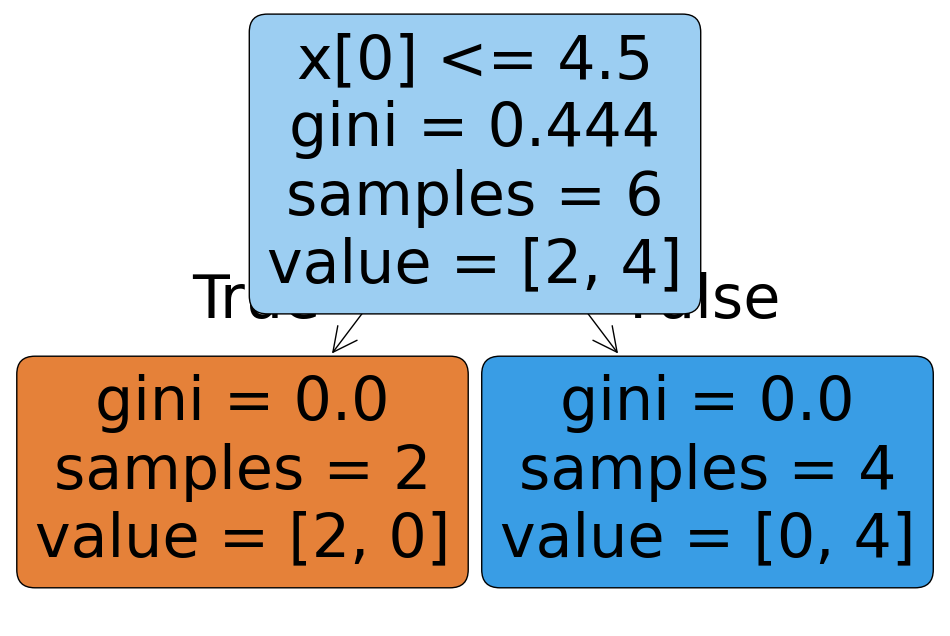

In [15]:
display_tree(dt1)

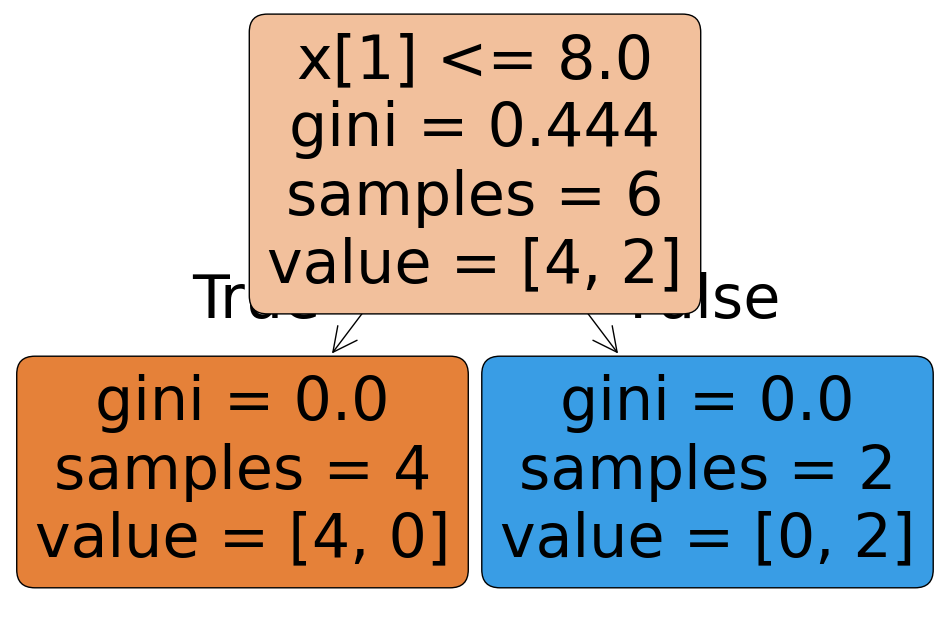

In [16]:
display_tree(dt2)

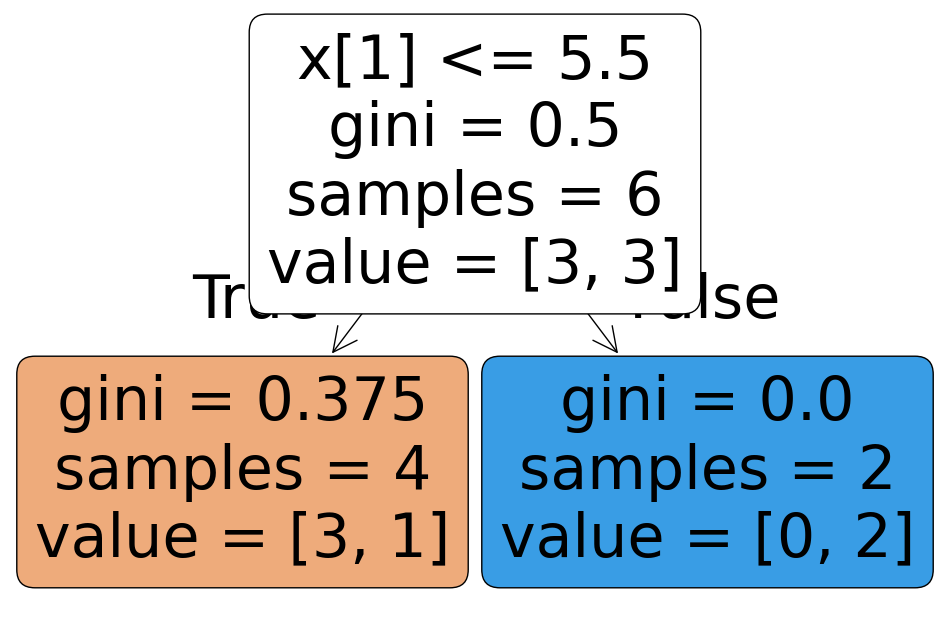

In [17]:
display_tree(dt3)

# Training a random forest using sklearn

In [21]:
from sklearn.ensemble import RandomForestClassifier
random_forest_classifier = RandomForestClassifier(random_state=0, n_estimators=5)
random_forest_classifier.fit(features, labels)
random_forest_classifier.score(features, labels)
#n_estimators = number of trees.
#max_depth=1

0.8888888888888888

/Users/khanhlinhpham/Documents/manning/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


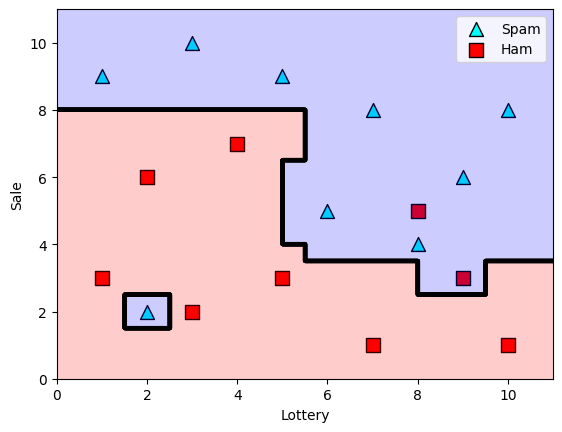

In [22]:
plot_model(features, labels, random_forest_classifier)

****************************** Estimator ******************************


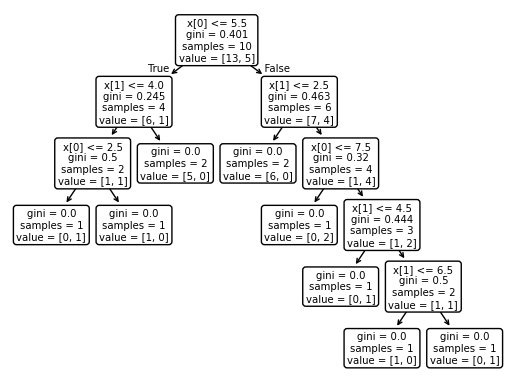

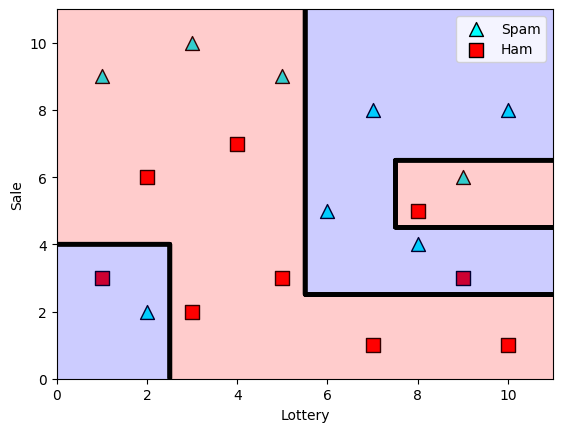

****************************** Estimator ******************************


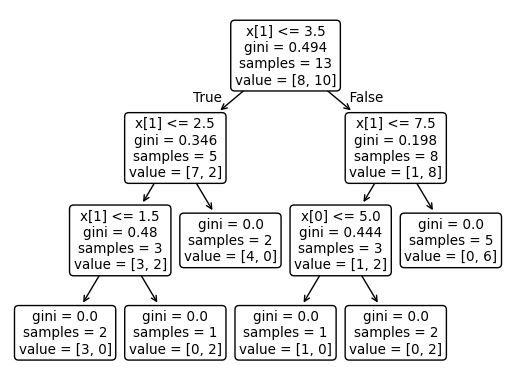

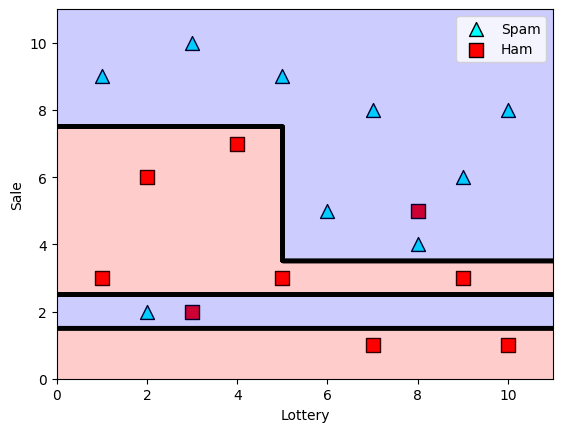

****************************** Estimator ******************************


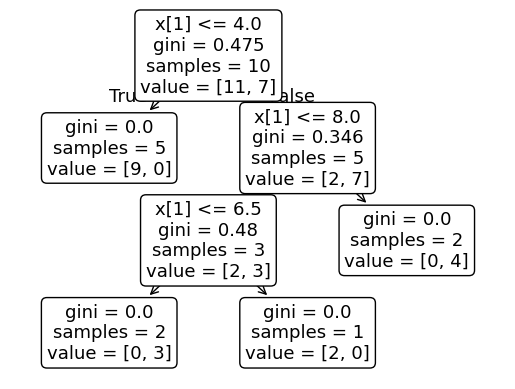

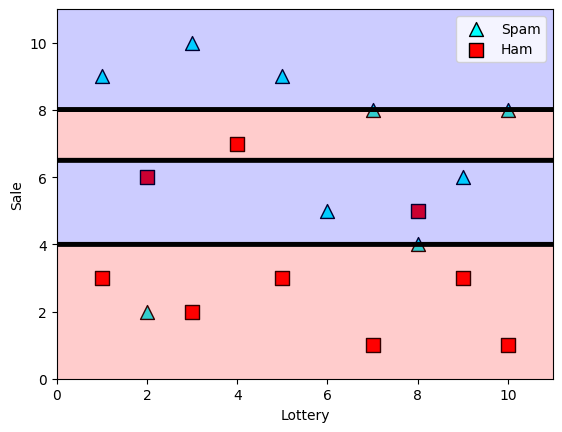

****************************** Estimator ******************************


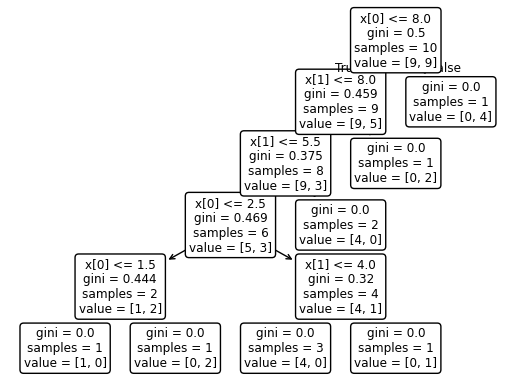

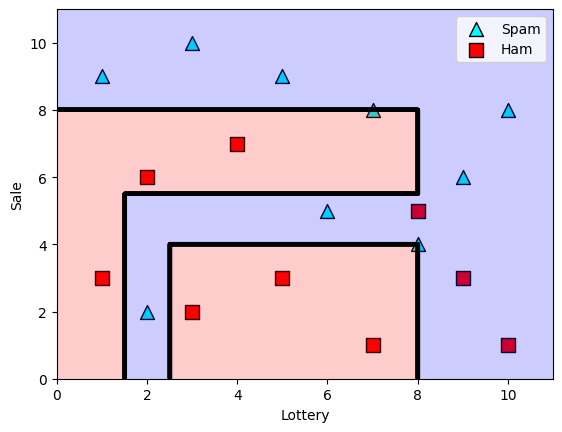

****************************** Estimator ******************************


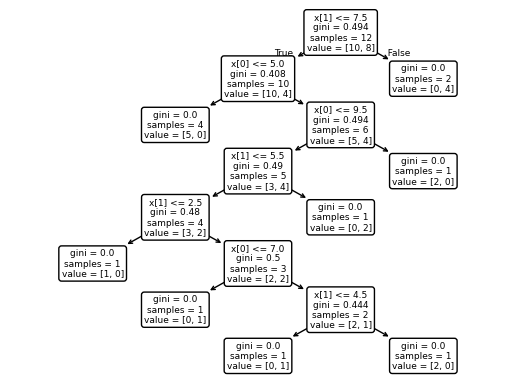

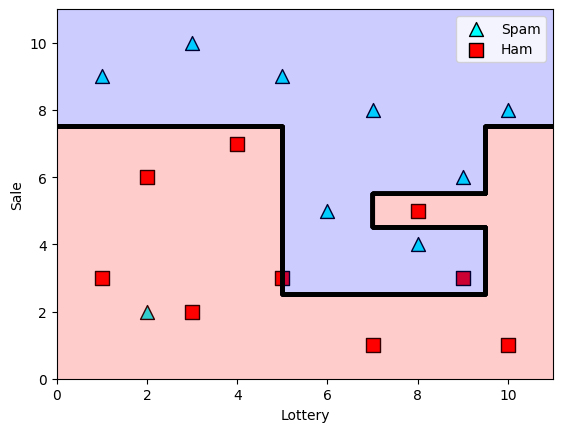

In [23]:
for dt in random_forest_classifier.estimators_:
    print("*"*30, "Estimator", "*"*30)
    tree.plot_tree(dt, rounded=True)
    plt.show()
    plot_model(features, labels, dt)
    plt.show()

# AdaBoost

In [24]:
from sklearn.ensemble import AdaBoostClassifier
# Set the random_state so that we always get the same results
adaboost_classifier = AdaBoostClassifier(random_state=0, n_estimators=6)
adaboost_classifier.fit(features, labels)
adaboost_classifier.score(features, labels)

0.7777777777777778

/Users/khanhlinhpham/Documents/manning/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


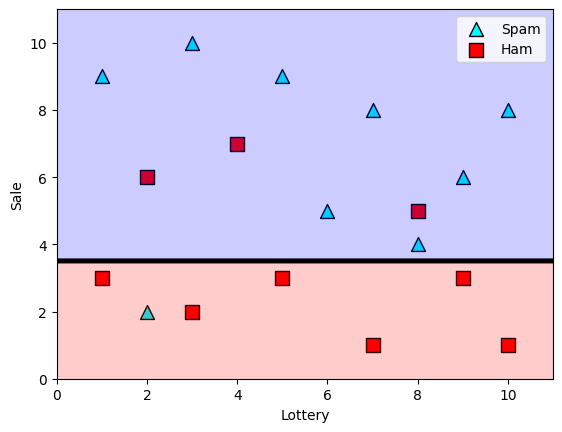

In [25]:
plot_model(features, labels, adaboost_classifier)

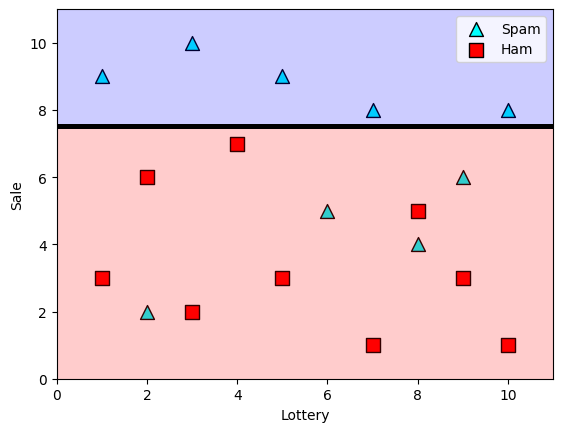

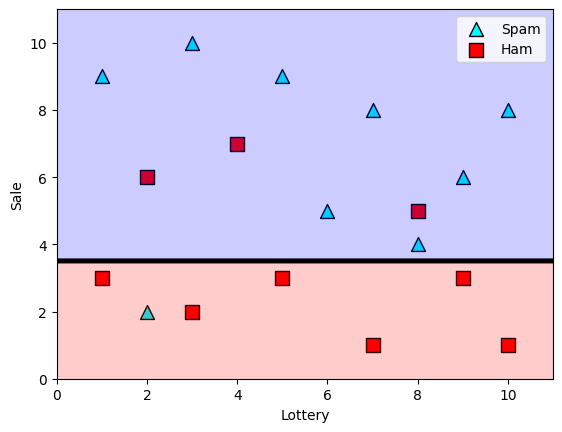

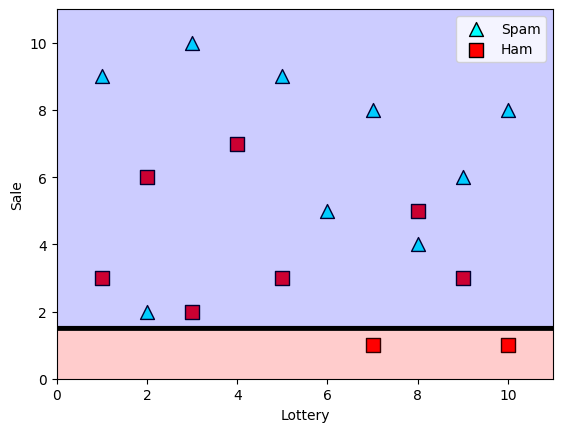

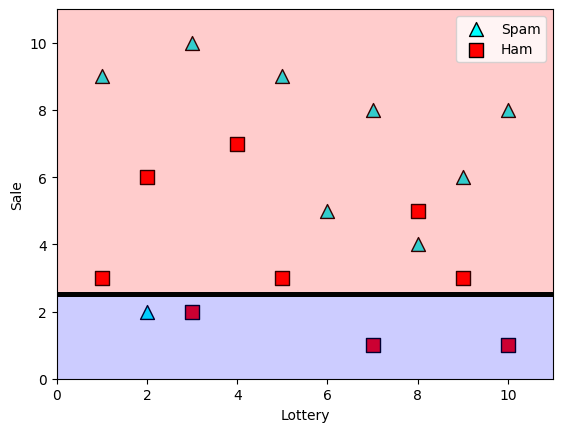

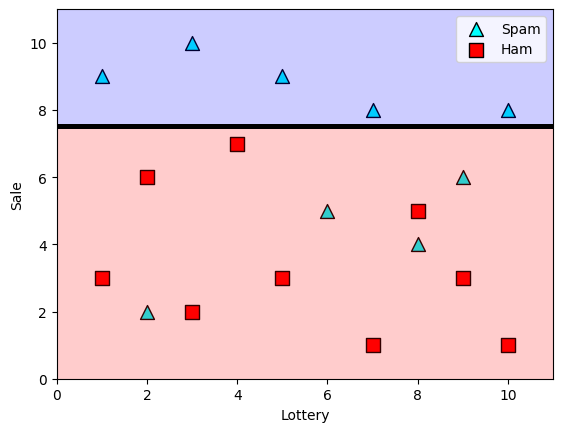

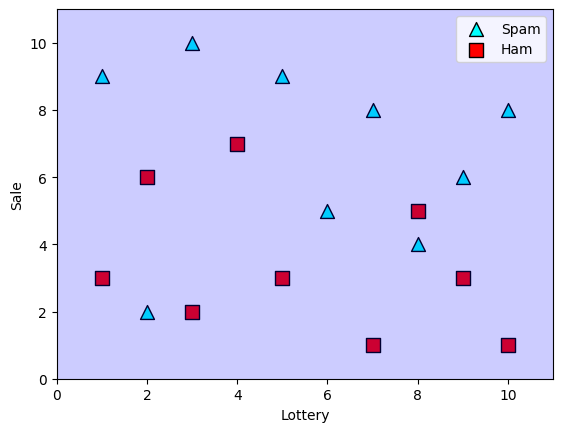

In [26]:
estimators = adaboost_classifier.estimators_
for estimator in estimators:
    plot_model(features, labels, estimator)
    plt.show()

/Users/khanhlinhpham/Documents/manning/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


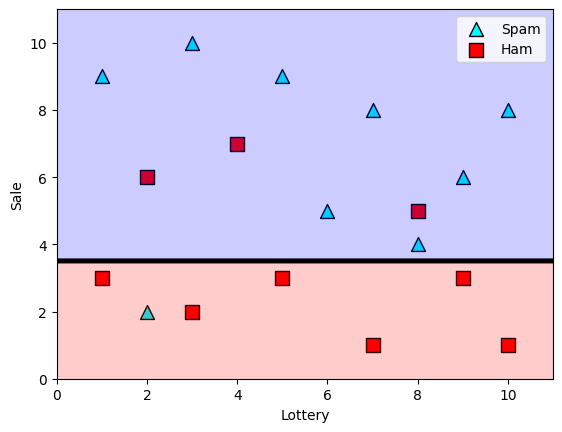

In [27]:
plot_model(features, labels, adaboost_classifier)

# Bonus: applying gradient boosting and XGBoost to the spam dataset

Note: the chapter covers these algorithms in regression mode on a different dataset, but here are the results of applying gradient boosting and XGBoost to this spam dataset. Notice that both models give predictions that are accurate, yet far from overfitting, which is a characteristic of boosting models.

# Gradient boosting

In [28]:
from sklearn.ensemble import GradientBoostingClassifier
gradient_boosting_classifier = GradientBoostingClassifier(random_state=0, n_estimators=5)
gradient_boosting_classifier.fit(features, labels)
gradient_boosting_classifier.score(features, labels)

0.8888888888888888

/Users/khanhlinhpham/Documents/manning/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


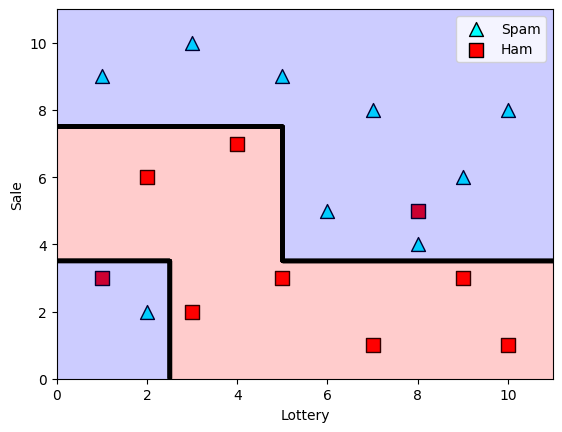

In [29]:
plot_model(features, labels, gradient_boosting_classifier)

In [30]:
estimators = gradient_boosting_classifier.estimators_

As an example, let us plot the first of the estimators.

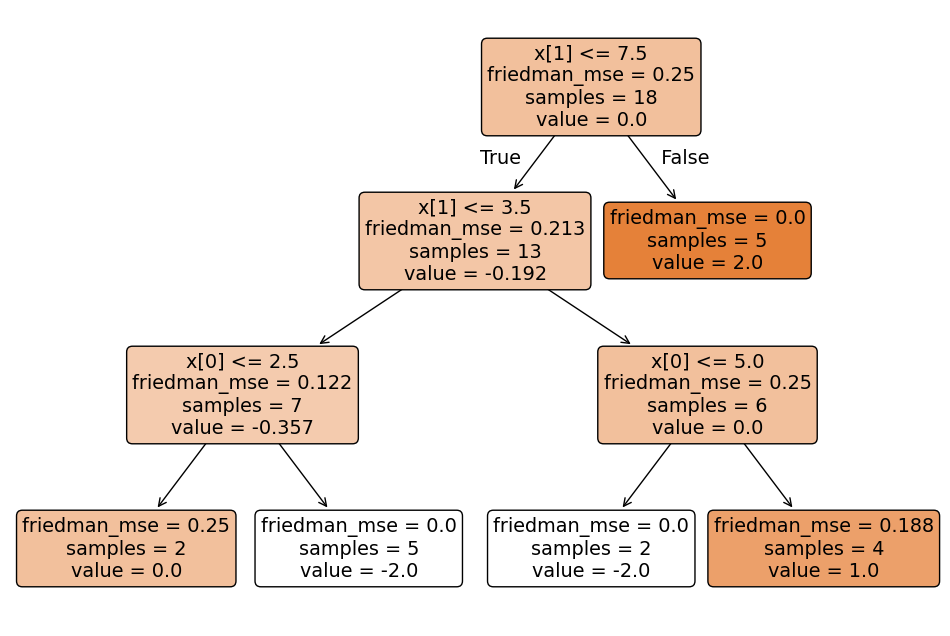

In [31]:
display_tree(estimators[0][0])

# XGBoost

In [32]:
import xgboost
from xgboost import XGBClassifier
xgboost_classifier = XGBClassifier(random_state=0, n_estimators=5)
xgboost_classifier.fit(np.array(features), labels)
xgboost_classifier.score(np.array(features), labels)

0.8888888888888888

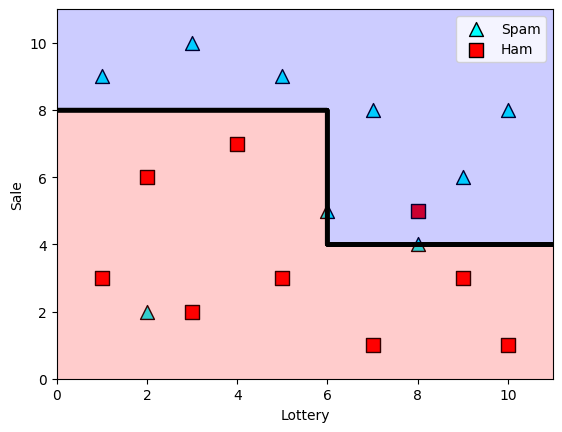

In [33]:
plot_model(features, labels, xgboost_classifier)

Here is the first of the estimators

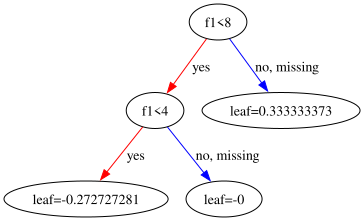

In [34]:
xgboost.to_graphviz(xgboost_classifier, num_trees=0)